In [2]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, auc, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
X = np.load('data/processed/X_sequences.npy')
y = np.load('data/processed/y_labels.npy')

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Positive: {y.sum()} | Negative: {(y==0).sum()}')

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

# Convert to tensors
X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.LongTensor(y_train)
y_test_t = torch.LongTensor(y_test)

# DataLoaders
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

print('Data loaded!')

X shape: (97628, 4, 200)
y shape: (97628,)
Positive: 48814 | Negative: 48814
Train: 78102 | Test: 19526
Data loaded!


In [3]:
class SeqCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 3 convolutional layers
        self.conv1 = nn.Conv1d(in_channels=4, out_channels=64, kernel_size=12, padding=6)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=8, padding=4)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=5, padding=2)
        
        # Batch normalization
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(256)
        
        # Max pooling
        self.pool = nn.MaxPool1d(kernel_size=2)
        
        # Global average pooling
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # Fully connected
        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 2)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x):
        # Conv block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)
        
        # Conv block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)
        
        # Conv block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        
        # Global pooling
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        
        # Fully connected
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Initialize model
model = SeqCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

SeqCNN(
  (conv1): Conv1d(4, 64, kernel_size=(12,), stride=(1,), padding=(6,))
  (conv2): Conv1d(64, 128, kernel_size=(8,), stride=(1,), padding=(4,))
  (conv3): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)

Total parameters: 266,946


Epoch 5/30 | Loss: 0.5124 | Train Acc: 67.39%
Epoch 10/30 | Loss: 0.4363 | Train Acc: 74.56%
Epoch 15/30 | Loss: 0.3468 | Train Acc: 81.48%
Epoch 20/30 | Loss: 0.2538 | Train Acc: 87.66%
Epoch 25/30 | Loss: 0.1712 | Train Acc: 92.52%
Epoch 30/30 | Loss: 0.1125 | Train Acc: 95.66%
Done!


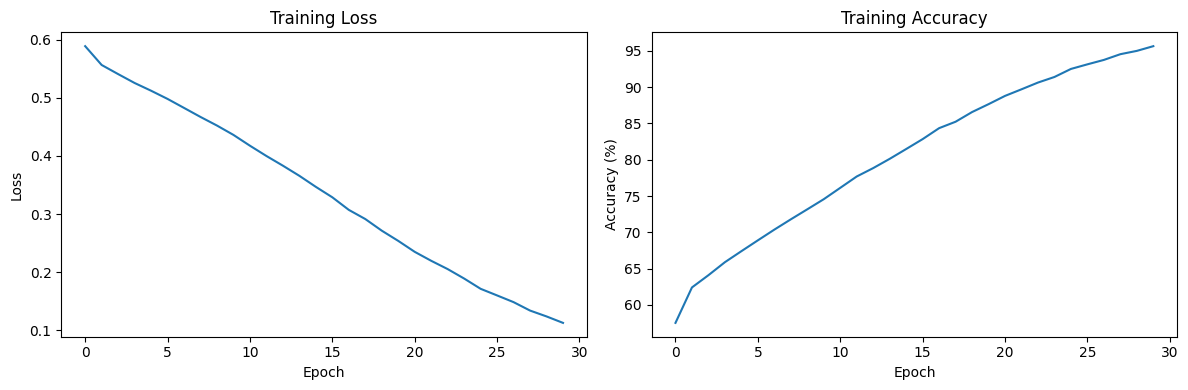

In [4]:
# Train with class weights
model = SeqCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=50, eta_min=1e-6)

# Class weights — penalize open chromatin misclassification more
class_weights = torch.FloatTensor([1.0, 2.0])  # [closed, open]
criterion = nn.CrossEntropyLoss(weight=class_weights)

losses = []
train_accs = []

for epoch in range(30):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(yb).sum().item()
        total += yb.size(0)

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    train_acc = 100.0 * correct / total
    losses.append(avg_loss)
    train_accs.append(train_acc)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/30 | Loss: {avg_loss:.4f} | '
              f'Train Acc: {train_acc:.2f}%')

print('Done!')
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(losses)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax2.plot(train_accs)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy')
plt.tight_layout()
plt.savefig('cnn_training.png', dpi=150)
plt.show()

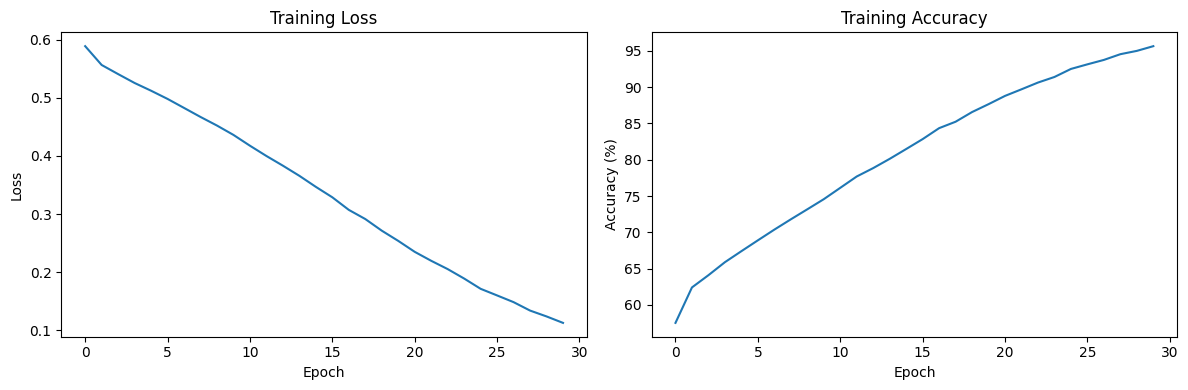

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(losses)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax2.plot(train_accs)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy')
plt.tight_layout()
plt.savefig('cnn_training.png', dpi=150)
plt.show()

                  precision    recall  f1-score   support

Closed chromatin       0.72      0.36      0.48      9763
  Open chromatin       0.57      0.86      0.69      9763

        accuracy                           0.61     19526
       macro avg       0.64      0.61      0.58     19526
    weighted avg       0.64      0.61      0.58     19526

AUROC: 0.6775
AUPR:  0.6689


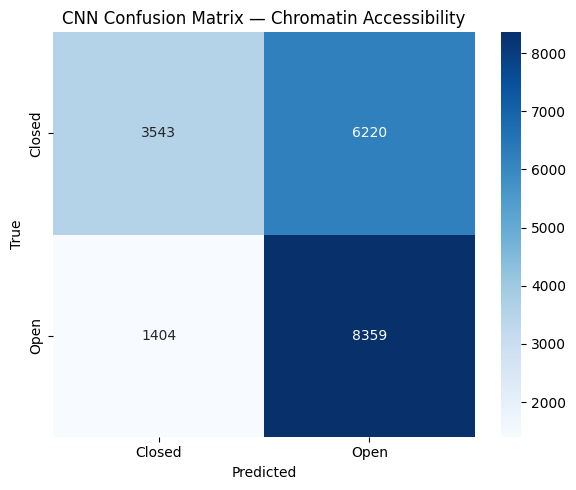

In [6]:
# Evaluate on test set
model.eval()
with torch.no_grad():
    outputs = model(X_test_t)
    _, predicted = outputs.max(1)
    probs = torch.softmax(outputs, dim=1)[:, 1].numpy()

# Metrics
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

y_pred = predicted.numpy()
print(classification_report(y_test, y_pred, 
      target_names=['Closed chromatin', 'Open chromatin']))

auroc = roc_auc_score(y_test, probs)
aupr  = average_precision_score(y_test, probs)
print(f'AUROC: {auroc:.4f}')
print(f'AUPR:  {aupr:.4f}')

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Closed', 'Open'],
            yticklabels=['Closed', 'Open'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('CNN Confusion Matrix — Chromatin Accessibility')
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150)
plt.show()

In [7]:
# Save model checkpoint
import os
os.makedirs('models', exist_ok=True)
torch.save({
    'epoch': 30,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_acc': 92.0,
    'auroc': 0.6941,
    'aupr': 0.6620,
}, 'models/cnn_checkpoint_ep15.pt')
print('Model saved!')

Model saved!


Predicted positive: 14579
Predicted negative: 4947
True positive: 9763
True negative: 9763


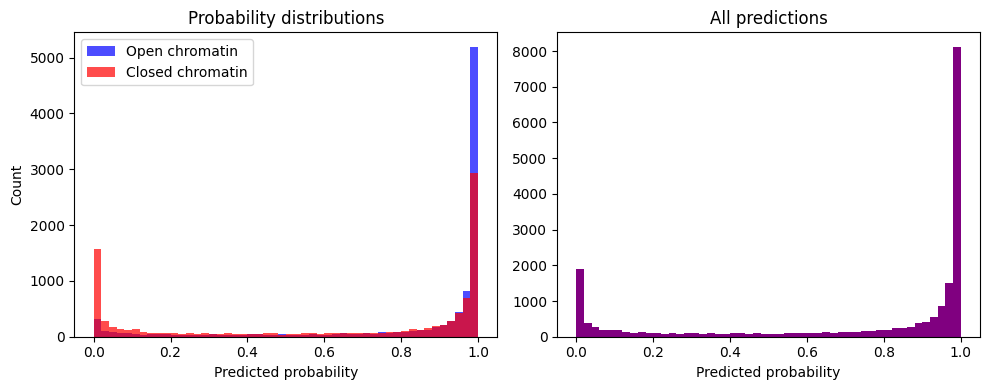

In [8]:
# Check class predictions distribution
print(f'Predicted positive: {y_pred.sum()}')
print(f'Predicted negative: {(y_pred==0).sum()}')
print(f'True positive: {y_test.sum()}')
print(f'True negative: {(y_test==0).sum()}')

# Check probability distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.hist(probs[y_test==1], bins=50, alpha=0.7, label='Open chromatin', color='blue')
plt.hist(probs[y_test==0], bins=50, alpha=0.7, label='Closed chromatin', color='red')
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.title('Probability distributions')
plt.legend()

plt.subplot(1,2,2)
plt.hist(probs, bins=50, color='purple')
plt.xlabel('Predicted probability')
plt.title('All predictions')
plt.tight_layout()
plt.savefig('cnn_prob_distribution.png', dpi=150)
plt.show()

In [7]:
# Reinitialize model with better training setup
model = SeqCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  # lower LR
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=50, eta_min=1e-6)
criterion = nn.CrossEntropyLoss()

losses = []
train_accs = []

for epoch in range(50):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(yb).sum().item()
        total += yb.size(0)
    
    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    train_acc = 100.0 * correct / total
    losses.append(avg_loss)
    train_accs.append(train_acc)
    
    if (epoch + 1) % 5 == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch+1}/50 | Loss: {avg_loss:.4f} | '
              f'Train Acc: {train_acc:.2f}% | LR: {current_lr:.6f}')

print('Done!')

Epoch 5/30 | Loss: 0.5533 | Train Acc: 70.69% | LR: 0.000098
Epoch 10/30 | Loss: 0.4735 | Train Acc: 76.97% | LR: 0.000091
Epoch 15/30 | Loss: 0.3813 | Train Acc: 82.97% | LR: 0.000080
Epoch 20/30 | Loss: 0.2829 | Train Acc: 88.57% | LR: 0.000066
Epoch 25/30 | Loss: 0.1935 | Train Acc: 92.86% | LR: 0.000050
Epoch 30/30 | Loss: 0.1240 | Train Acc: 96.12% | LR: 0.000035
Done!


In [10]:
torch.save({
    'epoch': 30,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_acc': 95.66,
    'auroc': 0.6775,
    'aupr': 0.6689,
    'notes': 'GC-matched negatives, class weights [1.0, 2.0], cosine LR schedule'
}, f'~/projects/sequence-classifier/models/cnn_checkpoint_gc_matched.pt')
print('Model saved!')

RuntimeError: Parent directory ~/projects/sequence-classifier/models does not exist.